In [1]:
from nautilus import Prior, Sampler
import numpy as np
from scipy.stats import norm
from getdist import plots, MCSamples

import sys
sys.path.append('../')
from src import IO, load_config, redshift_distributions

# Load the Fisher Matrix

In [2]:
config = load_config('../configs/config_DESC_vanilla.yaml')
fm = IO.load_fisher_matrix(config, 'fm_sampling_validation')

### Load the redshift error priors

In [3]:
N_z_bins = config.redshift_distributions.sources.N_z_bins
z_arr = np.linspace(config.forecast.z_min, config.forecast.z_max,
                    config.forecast.N_z_values)
nz_arr, zbin_edges = (
    redshift_distributions.get_redshift_distributions(
        z_arr, N_z_bins,
        config.redshift_distributions.sources.z0,
        config.redshift_distributions.sources.a,
        config.redshift_distributions.sources.sigma_z))
mean_z = np.trapz(nz_arr * z_arr, z_arr)
scale_z = config.redshift_distributions.sources.sigma_delta_z*(1+mean_z)

# Load the Nautilus sampler
### Match the priors to the ones in the Nautilus run

In [4]:
filename = 'DESC_vanilla.hdf5'

# Priors
prior = Prior()
for ip, p in enumerate(config.sampling_validation.keys()):
    if config.sampling_validation[p] is None:
        continue
    elif p=='delta_z':
        for i in range(N_z_bins):
            prior.add_parameter(f'dz_{i + 1}', dist=norm(loc=0.0,
                scale=config.redshift_distributions.sources.sigma_delta_z*(1 + mean_z[i])))
    elif len(config.sampling_validation[p]) == 2:
        prior.add_parameter(p, dist=tuple(config.sampling_validation[p]))
    else:
        raise ValueError(f'Input parameter in config file had problem: {p}')

sampler = Sampler(prior, lambda x: 1., filepath=filename)

In [7]:
points, log_w, log_l = sampler.posterior()
ndim = points.shape[1]

gd_samples_nautilus = MCSamples(samples=points,
                                 weights=np.exp(log_w),
                                 loglikes=log_l,
                                 names = fm.parameters,
                                 labels = [x.strip('$') for x in fm.latex_parameters],
                                 label='Nautilus',
                                 sampler='nested')

Removed no burn in


# Plot the posterior and the Fisher matrix

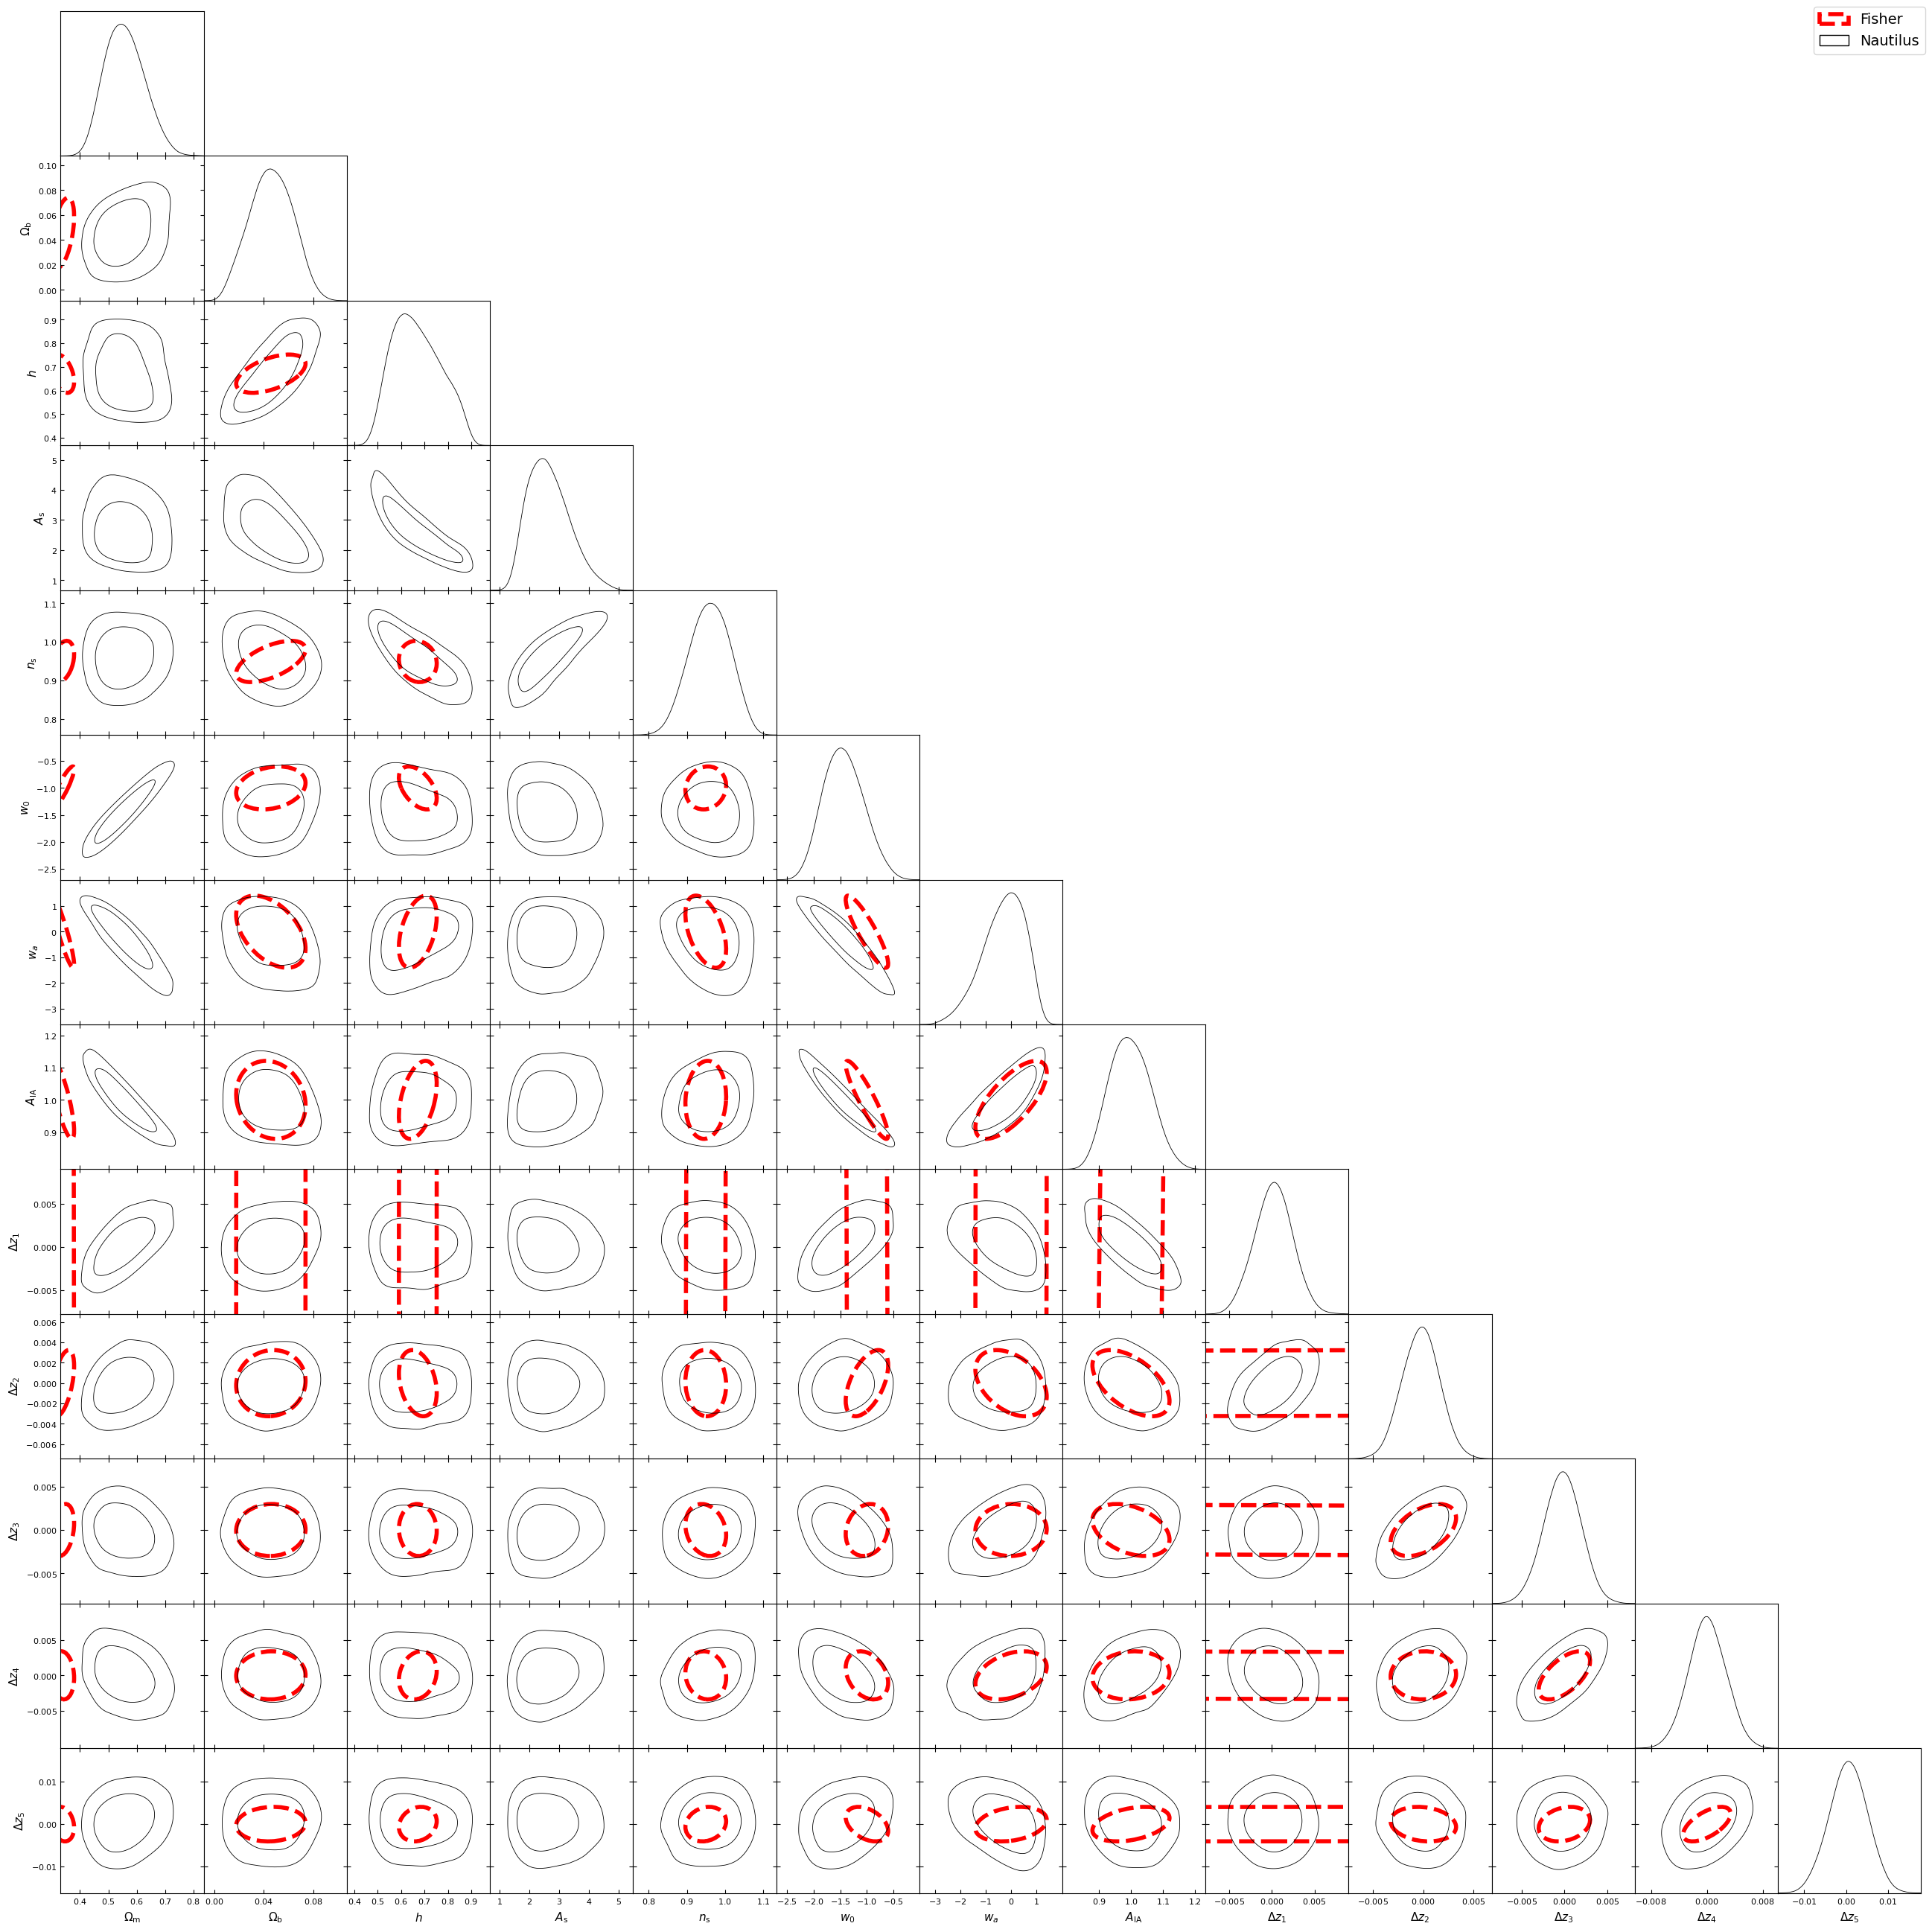

In [8]:
# Triangle plot
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 2
g.triangle_plot([gd_samples_nautilus])

for p2i in range(ndim): # row
    for p1i in range(p2i): # column
        ax = g.subplots[p2i, p1i]
        mu = [fm.fiducial_parameters[p1i], fm.fiducial_parameters[p2i]]
        ax, xlim, ylim, mu, latex = fm.draw_covariance_ellipse(ax, [fm.parameters[p1i], fm.parameters[p2i]],
            CL=0.68, color='r', fill=False, ls='--', label='Fisher', linewidth=4)

handles, legend_labels = ax.get_legend_handles_labels()
from matplotlib.patches import Patch
handles.append(Patch(facecolor='white', edgecolor='k'))
legend_labels.append('Nautilus')
g.fig.legend(handles, legend_labels, fontsize=14, loc='upper right')